In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print(os.getcwd())
tfrecordpath = "../Data/tfrecords/"


2025-02-07 17:12:05.709456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738944725.720457   26261 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738944725.724225   26261 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-07 17:12:05.737861: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/mnt/c/Users/alexs/Desktop/levbot/Training


### Load in data
#### Define schema


In [2]:
def decode(record_bytes):
    # Function for parsing each record in the tf files
    example = tf.io.parse_single_example(
        # Data
        record_bytes,

        # Schema
        {
        'Timeframe': tf.io.FixedLenFeature([], tf.string),
        'timestamp': tf.io.RaggedFeature(dtype=tf.int64),
        'Open': tf.io.RaggedFeature(dtype=tf.float32),
        'High': tf.io.RaggedFeature(dtype=tf.float32),
        'Low': tf.io.RaggedFeature(dtype=tf.float32),
        'Close': tf.io.RaggedFeature(dtype=tf.float32),
        'Volume': tf.io.RaggedFeature(dtype=tf.float32),
        }
        )

    return example

In [3]:
def getDataset(path):
    ds = tf.data.TFRecordDataset(path,  num_parallel_reads = tf.data.AUTOTUNE)
    ds = ds.map(decode, num_parallel_calls = tf.data.AUTOTUNE)
    return ds



In [4]:
import TensorSlider
ws = slider().__iter__()

NameError: name 'slider' is not defined

In [27]:
# Testing slicing


print(ws.speedslider.tensors.shape)
res = ws.__next__()
data = tf.convert_to_tensor(res[1])
print(ws.speedslider.iterationcount)
ws.speedslider.iterationcount = 2350
print(ws.speedslider.tensors.shape[2]/ws.speedslider.batchsize)
print(ws.speedslider.tensors.dtype)
shape = data.shape
print(data.shape)

dividepricesby = tf.reshape(data[:,0,0,0], (shape[0], 1, 1, 1))
print(dividepricesby.shape)
prices = tf.divide(data[:,:,0:4], dividepricesby) # divide by latest base timeframe close
prices -= 1 # zero out
prices *= 10 # convert to 1/10 percentage, so 1 = 10 percent

low = tf.reduce_min(prices[:,0,2], 1)
high = tf.reduce_max(prices[:,0,1], 1)

label = tf.stack([low, high], axis = 1)
print(label.shape)

(6, 6, 2348150)
2351
23481.5
float32
(100, 6, 5, 6)
(100, 1, 1, 1)
(100, 2)


In [5]:
windowsize = 100
lookahead = 5
batchsize = 100

def slider():


    path = tfrecordpath + "BTCUSD_PERP/{tframe}.tfrecord"
    datasets = {"1m" : getDataset(path.format(tframe="1m")),
                "3m":  getDataset(path.format(tframe="3m")),
                "5m":  getDataset(path.format(tframe="5m")),
                "15m":  getDataset(path.format(tframe="15m")),
                "30m":  getDataset(path.format(tframe="30m")),
                "1h":  getDataset(path.format(tframe="1h"))}
    return TensorSlider.RandomWindowSlider(datasets, windowsize, lookahead, batchsize=batchsize)

dataset = tf.data.Dataset.from_generator(slider,
    output_signature=(
        tf.TensorSpec((batchsize, 6,5,windowsize), dtype=tf.float32),
        tf.TensorSpec((batchsize, 6, 5, lookahead+1), dtype=tf.float32))
    )

I0000 00:00:1738944406.552226   24291 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5188 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:05:00.0, compute capability: 8.6


In [7]:
def createLabelsBatch(data, lookforward):
    """
    create input labels from the lookahead data
    """

    shape = lookforward.shape

    dividepricesby = tf.reshape(lookforward[:,0,0,0], (shape[0], 1, 1, 1))
    prices = tf.divide(lookforward[:,:,0:4], dividepricesby) # divide by latest base timeframe close
    prices -= 1 # zero out
    prices *= 10 # convert to 1/10 percentage, so 1 = 10 percent

    low = tf.reduce_min(prices[:,0,2], 1)
    high = tf.reduce_max(prices[:,0,1], 1)

    label = tf.stack([low, high], axis = 1)



    shape = data.shape
    # data processing, format: batch, timeframe, feature(ohlcv), window (ascending time)
    # prices
    dividepricesby = tf.reshape(data[:,0,3,-1], (shape[0], 1, 1, 1))
    prices = tf.divide(data[:,:,0:4], dividepricesby) # divide by latest base timeframe close
    prices -= 1 # zero out
    prices *= 10 # convert to 1/10 percentage, so 1 = 10 percent

    volumes = tf.reshape(data[:,:,4], (shape[0], shape[1], 1, shape[3]))
    dividebyvolume = tf.reshape(data[:,:,4,-1], (shape[0], shape[1], 1, 1))
    volume = tf.divide(volumes, dividebyvolume) # divide by latest volume (of each timeframe)
    volume -= 1
    volume *= 10 # convert to 1/10 percentage, so 1 = 10 percent

    data = tf.clip_by_value(tf.concat([prices, volume], axis=2), -2, 2)
    # remove nans
    data, label = tf.keras.ops.nan_to_num(data), tf.keras.ops.nan_to_num(label)

    return data, label

def decode(record_bytes):
    # Function for parsing each record in the tf files
    example = tf.io.parse_single_example(
        # Data
        record_bytes,

        # Schema
        {
        'Timeframe': tf.io.FixedLenFeature([], tf.string),
        'timestamp': tf.io.RaggedFeature(dtype=tf.int64),
        'Open': tf.io.RaggedFeature(dtype=tf.float32),
        'High': tf.io.RaggedFeature(dtype=tf.float32),
        'Low': tf.io.RaggedFeature(dtype=tf.float32),
        'Close': tf.io.RaggedFeature(dtype=tf.float32),
        'Volume': tf.io.RaggedFeature(dtype=tf.float32),
        }
        )

    return example

def getDataset(path):
    ds = tf.data.TFRecordDataset(path,  num_parallel_reads = tf.data.AUTOTUNE)
    ds = ds.map(decode, num_parallel_calls = tf.data.AUTOTUNE)
    return ds

In [8]:
def createLabels(data, lookforward):
    """
    create input labels from the lookaehad data
    """

    ohlc = lookforward
    ohlc /= ohlc[0,:] # divide by open price
    ohlc -= 1 # zero out
    ohlc *= 100 # convert to 1/10 percentage, so 1 = 10 percent
    ohlc = tf.clip_by_value(ohlc,-1,1)
    high = ohlc[tf.math.argmax(ohlc[:,1]), 1]
    low = ohlc[tf.math.argmin(ohlc[:,2]), 2]


    # same process, compute relative deltas
    processed = []
    latestClose = data[0,3,0] # base timeframe
    pricemult = 10 # 1 = 10 percent
    volmult = 0.1
    for i in range(0, data.shape[0]):
        # lets go timeframe by timeframe
        prices = tf.divide(data[i,0:4,:], latestClose) - 1
        prices = tf.multiply(prices, pricemult)
        volumes = tf.divide(data[i,4,:], data[i,4,0]) - 1
        volumes = tf.multiply(volumes, volmult)
        volumes = tf.expand_dims(volumes, 0)
        processed.append(tf.concat([prices, volumes], axis=0))

    datares = tf.clip_by_value(tf.stack(processed, axis=0), clip_value_min=-1, clip_value_max=1)

    # remove nans
    datares = tf.keras.ops.nan_to_num(datares)

    return tf.expand_dims(datares,0), [low, high]

In [9]:
def printtimeframe(features):
    # batch, timeframe, feature
    batch = features[0]
    #plt.plot(batch[0, 0])
    print(batch.shape)
    for i in range(0, batch.shape[0]):
        plt.plot(batch[i, 3])
        #plt.show()
    plt.xlim(90,101)
    plt.ylim(-0.1, 0.1)
    plt.legend(['1m', '3m', "5m", "15m", "30m", "1h"], loc='best')
    plt.show()

Time taken for 102 calls: 0.09753799438476562s, thats 0.96ms per call
(6, 5, 100)


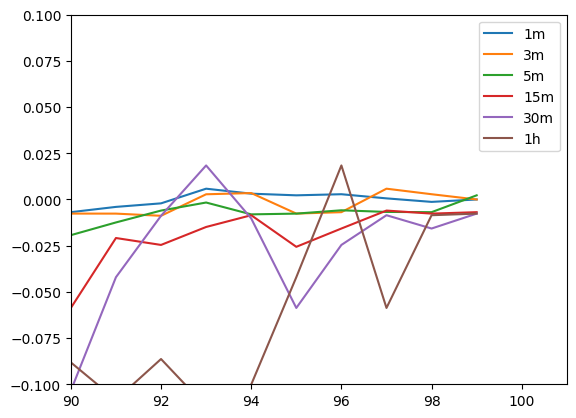

In [10]:
iterate_over = dataset.map(createLabelsBatch)

import time
t0 = None
for i, data in enumerate(iterate_over):
    if np.any((tf.math.is_nan(data[0]))):
        print("NaN in data")
    if i == 0:
        t0 = time.time()
    if i > 100:
        tdelta = time.time() - t0
        print(f"Time taken for {i+1} calls: {tdelta}s, thats {((tdelta/(i+1))*1000):.2f}ms per call")
        printtimeframe(data[0])
        break
        

In [11]:
import keras
path = "models/modeltest/model.keras"
model = keras.models.load_model(path)
history = model.fit(dataset.map(createLabels),
                        epochs=1, verbose=1,
                        validation_data=None, callbacks=None)

ValueError: File not found: filepath=models/modeltest/model.keras. Please ensure the file is an accessible `.keras` zip file.